In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from google.colab import drive
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import classification_report
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [ ]:

# EXTRAÇÃO

drive.mount('/content/drive', force_remount=True)

print("Carregando dados...")

base_path = "/content/drive/Shareddrives/Data Project - Equipe 3/Dados"

df_dengue = pd.read_csv(f"{base_path}/dengue_full.csv", usecols=['DT_NOTIFIC','ID_MUNICIP'])
df_chuva = pd.read_csv(f"{base_path}/daee_pluviometrico_2015_2019.csv", usecols=['date','cod_ibge','value'])
df_temp = pd.read_csv(f"{base_path}/nasa_power_sp_municipal_climate_monthly.csv")
df_pop = pd.read_csv(f"{base_path}/ibge_sp_municipalities.csv")

Mounted at /content/drive
Carregando dados...


In [ ]:
# 1. Ajuste da População (Gabarito de 645 cidades)
df_pop = df_pop[['municipality_ibge_code', 'population_estimated', 'latitude', 'longitude']].copy()
df_pop.columns = ['codigo_ibge', 'populacao', 'latitude', 'longitude']

# Forçar 6 dígitos (corta o 7º dígito verificador para igualar à Dengue)
df_pop['codigo_ibge'] = df_pop['codigo_ibge'].astype(str).str[:6].astype(int)

print(f"População: {df_pop.shape[0]} cidades carregadas.")
df_pop.head(3)

População: 645 cidades carregadas.


,codigo_ibge,populacao,latitude,longitude
0,350010,35673,-21.573845,-51.056587
1,350020,4505,-21.291283,-49.655419
2,350030,32886,-22.048863,-47.040315


In [ ]:
#  DENGUE


# 1. Converter data para datetime
df_dengue['DT_NOTIFIC'] = pd.to_datetime(df_dengue['DT_NOTIFIC'], errors='coerce')

# 2. Criar colunas de ano e mes
df_dengue['ano'] = df_dengue['DT_NOTIFIC'].dt.year
df_dengue['mes'] = df_dengue['DT_NOTIFIC'].dt.month

# 3. Padronizar ID_MUNICIP para codigo_ibge (6 dígitos inteiros)
df_dengue = df_dengue.dropna(subset=['ID_MUNICIP'])
df_dengue['codigo_ibge'] = df_dengue['ID_MUNICIP'].astype(int).astype(str).str[:6].astype(int)

# 4. Filtrar período (2015-2019) e apenas municípios que estão no nosso gabarito (df_pop)
lista_645 = df_pop['codigo_ibge'].unique()
df_dengue_m = df_dengue[
    (df_dengue['ano'].between(2015, 2019)) &
    (df_dengue['codigo_ibge'].isin(lista_645))
].copy()

# 5. Agrupar para contar casos por mês
df_dengue_m = df_dengue_m.groupby(['codigo_ibge', 'ano', 'mes']).size().reset_index(name='casos')

print(f"Dengue: {df_dengue_m['codigo_ibge'].nunique()} cidades processadas.")
df_dengue_m.head(3)

Dengue: 645 cidades processadas.


,codigo_ibge,ano,mes,casos
0,350010,2015,1,16
1,350010,2015,2,65
2,350010,2015,3,392


In [ ]:
#  CHUVA: PLUVIOMETRIA E TRATAMENTO DE OUTLIERS

# 1. Carregar novamente (caso tenha sido apagada da memória)
df_chuva = pd.read_csv(f"{base_path}/daee_pluviometrico_2015_2019.csv", usecols=['date','cod_ibge','value'])

# 2. Converter data e criar colunas de tempo
df_chuva['date'] = pd.to_datetime(df_chuva['date'], errors='coerce')
df_chuva['ano'] = df_chuva['date'].dt.year
df_chuva['mes'] = df_chuva['date'].dt.month

# 3. Padronizar o ID para 6 dígitos
df_chuva['codigo_ibge'] = df_chuva['cod_ibge'].astype(str).str[:6].astype(int)

# 4. Filtrar período (2015-2019) e apenas os 645 municípios oficiais
df_chuva_m = df_chuva[
    (df_chuva['ano'].between(2015, 2019)) &
    (df_chuva['codigo_ibge'].isin(lista_645))
].copy()

# 5. Agrupar somando a chuva acumulada por município e mês
df_chuva_m = df_chuva_m.groupby(['codigo_ibge', 'ano', 'mes'])['value'].sum().reset_index(name='chuva_acumulada')

print(f"Chuva: {df_chuva_m['codigo_ibge'].nunique()} cidades processadas.")
df_chuva_m.head(3)

Chuva: 229 cidades processadas.


,codigo_ibge,ano,mes,chuva_acumulada
0,350050,2015,1,78.4
1,350050,2015,2,556.4
2,350050,2015,3,336.8


In [ ]:
# TEMPERATURA

# 1. Padronizar o ID para 6 dígitos e ajustar nomes das colunas de tempo
df_temp['codigo_ibge'] = df_temp['municipality_ibge_code'].astype(str).str[:6].astype(int)
df_temp.rename(columns={'year': 'ano', 'month': 'mes'}, inplace=True)

# 2. Filtrar período (2015-2019) e apenas os 645 municípios oficiais
df_temp_m = df_temp[
    (df_temp['ano'].between(2015, 2019)) &
    (df_temp['codigo_ibge'].isin(lista_645))
].copy()

# 3. Agrupar média de temperatura por município e mês
df_temp_m = df_temp_m.groupby(['codigo_ibge', 'ano', 'mes'])['avg_temperature_c'].mean().reset_index()

print(f"Temperatura: {df_temp_m['codigo_ibge'].nunique()} cidades processadas.")
df_temp_m.head(3)

Temperatura: 645 cidades processadas.


,codigo_ibge,ano,mes,avg_temperature_c
0,350010,2015,1,27.71
1,350010,2015,2,25.89
2,350010,2015,3,24.69


In [ ]:
# Recarregando apenas as colunas necessárias da df_pop original

df_pop = pd.read_csv(f"{base_path}/ibge_sp_municipalities.csv")
df_pop = df_pop[['municipality_ibge_code', 'municipality_name', 'population_estimated', 'latitude', 'longitude']].copy()

# Renomeando colunas
df_pop.columns = ['codigo_ibge', 'nome_municipio', 'populacao', 'latitude', 'longitude']

# Padronizando para 6 dígitos
df_pop['codigo_ibge'] = df_pop['codigo_ibge'].astype(str).str[:6].astype(int)

print(f"Gabarito atualizado com nomes: {df_pop.shape[0]} cidades.")
df_pop.head(3)

Gabarito atualizado com nomes: 645 cidades.


,codigo_ibge,nome_municipio,populacao,latitude,longitude
0,350010,Adamantina,35673,-21.573845,-51.056587
1,350020,Adolfo,4505,-21.291283,-49.655419
2,350030,Aguaí,32886,-22.048863,-47.040315


In [ ]:
# CRIANDO ESQUELETO PARA NÃO PERDER OS DADOS


# 1. Gerar todas as combinações de Ano e Mês (2015 a 2019)
anos = range(2015, 2020)
meses = range(1, 13)
combinacoes_tempo = pd.DataFrame([(a, m) for a in anos for m in meses], columns=['ano', 'mes'])

# 2. Gerar a lista de municípios (usando o gabarito df_pop)
municipios = df_pop[['codigo_ibge']].copy()

# 3. Criar o esqueleto completo (Cross Join)
# Isso vai gerar exatamente 38.700 linhas (645 * 60)
municipios['key'] = 1
combinacoes_tempo['key'] = 1
df_completo = pd.merge(municipios, combinacoes_tempo, on='key').drop('key', axis=1)

print(f"Esqueleto criado: {df_completo.shape[0]} linhas.")

Esqueleto criado: 38700 linhas.


In [ ]:
# Técnica de Integração Espacial - saber qual estação é a mais próxima de cada cidade. Em vez de preencher com zero, usaremos o vizinho mais próximo (Nearest Neighbor)


# 1. Identificar quais cidades têm dados reais de chuva
cidades_com_chuva = df_chuva_m['codigo_ibge'].unique()

# 2. Criar um "mapa" com as coordenadas dessas estações
df_estacoes = df_pop[df_pop['codigo_ibge'].isin(cidades_com_chuva)][['latitude', 'longitude', 'codigo_ibge']]

# 3. Treinar o buscador de vizinhos (KNN) para encontrar a 1 estação mais próxima
knn = KNeighborsRegressor(n_neighbors=1)
knn.fit(df_estacoes[['latitude', 'longitude']], df_estacoes['codigo_ibge'])

# 4. Criar o de/para: Cada cidade de SP agora aponta para sua estação de referência
df_pop['codigo_ibge_estacao'] = knn.predict(df_pop[['latitude', 'longitude']]).astype(int)

print("Mapeamento de vizinhos concluído!")
df_pop[['nome_municipio', 'codigo_ibge', 'codigo_ibge_estacao']].head()

Mapeamento de vizinhos concluído!


,nome_municipio,codigo_ibge,codigo_ibge_estacao
0,Adamantina,350010,353490
1,Adolfo,350020,350880
2,Aguaí,350030,353070
3,Agudos,350070,350600
4,Alambari,350075,351030


In [ ]:
# MERGE


# 1. Começamos com o Esqueleto (38.700 linhas)
df_final_v2 = df_completo.copy()

# 2. Unir Dengue e Temperatura (normal, pelo código da própria cidade)
df_final_v2 = pd.merge(df_final_v2, df_dengue_m, on=['codigo_ibge', 'ano', 'mes'], how='left')
df_final_v2 = pd.merge(df_final_v2, df_temp_m, on=['codigo_ibge', 'ano', 'mes'], how='left')

# 3. Trazer o de/para de estações para o esqueleto
df_final_v2 = pd.merge(df_final_v2, df_pop[['codigo_ibge', 'nome_municipio', 'populacao', 'latitude', 'longitude', 'codigo_ibge_estacao']], on='codigo_ibge', how='left')

# 4. O PONTO CHAVE: Unir a Chuva usando o 'codigo_ibge_estacao'
# Note que o 'left_on' usa o vizinho e o 'right_on' usa o código da chuva
df_final_v2 = pd.merge(
    df_final_v2,
    df_chuva_m[['codigo_ibge', 'ano', 'mes', 'chuva_acumulada']],
    left_on=['codigo_ibge_estacao', 'ano', 'mes'],
    right_on=['codigo_ibge', 'ano', 'mes'],
    how='left',
    suffixes=('', '_estacao')
)

# 5. Limpeza Final
df_final_v2['casos'] = df_final_v2['casos'].fillna(0)
df_final_v2['chuva_acumulada'] = df_final_v2['chuva_acumulada'].fillna(0)
df_final_v2['avg_temperature_c'] = df_final_v2.groupby('codigo_ibge')['avg_temperature_c'].transform(lambda x: x.fillna(x.mean()))

print(f" Novo Dataset com Voronoi pronto: {df_final_v2.shape}")

 Novo Dataset com Voronoi pronto: (38700, 12)


In [ ]:
# 1. Cálculo da Incidência
df_final_v2['incidencia'] = (df_final_v2['casos'] / df_final_v2['populacao']) * 10000

# 2. Ordenação Cronológica
df_final_v2 = df_final_v2.sort_values(by=['codigo_ibge', 'ano', 'mes'])

# 3. Criação de Lags (1 e 2 meses) para Temperatura e Chuva
for lag in [1, 2]:
    df_final_v2[f'temp_lag_{lag}'] = df_final_v2.groupby('codigo_ibge')['avg_temperature_c'].shift(lag)
    df_final_v2[f'chuva_lag_{lag}'] = df_final_v2.groupby('codigo_ibge')['chuva_acumulada'].shift(lag)

# 4. Remover os meses iniciais que ficaram com NaN (Jan e Fev de 2015)
df_final_v2 = df_final_v2.dropna(subset=['temp_lag_2', 'chuva_lag_2']).copy()

# 5. Definir o novo Target (Surto)
df_final_v2['surto'] = (df_final_v2['incidencia'] > 300).astype(int)

print(f"Variáveis de tempo e incidência criadas!")
print(f"Shape atualizado: {df_final_v2.shape}")
df_final_v2[['nome_municipio', 'mes', 'chuva_acumulada', 'chuva_lag_1', 'chuva_lag_2']].head()

Variáveis de tempo e incidência criadas!
Shape atualizado: (37410, 18)


,nome_municipio,mes,chuva_acumulada,chuva_lag_1,chuva_lag_2
2,Adamantina,3,208.4,179.8,198.8
3,Adamantina,4,59.0,208.4,179.8
4,Adamantina,5,120.6,59.0,208.4
5,Adamantina,6,16.4,120.6,59.0
6,Adamantina,7,143.2,16.4,120.6


In [ ]:
# NORMALIZAÇÃO / ESCALONAMENTO


# Features que serão escaladas
features_to_scale = ['temp_lag_1', 'temp_lag_2',
                     'chuva_lag_1', 'chuva_lag_2',
                     'latitude', 'longitude']

# Aplicando RobustScaler (melhor que StandardScaler por causa dos outliers na chuva)
scaler = RobustScaler()

# 1. Separar Treino (passado) e Teste (futuro)
df_train = df_final_v2[df_final_v2['ano'] < 2019].copy()
df_test  = df_final_v2[df_final_v2['ano'] == 2019].copy()

# 2. O JEITO CERTO (Sem Data Leakage):
# FIT_TRANSFORM no treino (aprende a escala e aplica)
df_train[features_to_scale] = scaler.fit_transform(df_train[features_to_scale])

# APENAS TRANSFORM no teste (usa a escala aprendida do passado no futuro)
df_test[features_to_scale] = scaler.transform(df_test[features_to_scale])

# 3. Unir novamente para as análises gráficas ficarem certas
df_final_v2 = pd.concat([df_train, df_test]).sort_values(by=['codigo_ibge', 'ano', 'mes'])

print("Normalização aplicada de forma segura (Sem Vazamento de Dados)!")
print(f"Features escaladas: {features_to_scale}")

Normalização aplicada de forma segura (Sem Vazamento de Dados)!
Features escaladas: ['temp_lag_1', 'temp_lag_2', 'chuva_lag_1', 'chuva_lag_2', 'latitude', 'longitude']


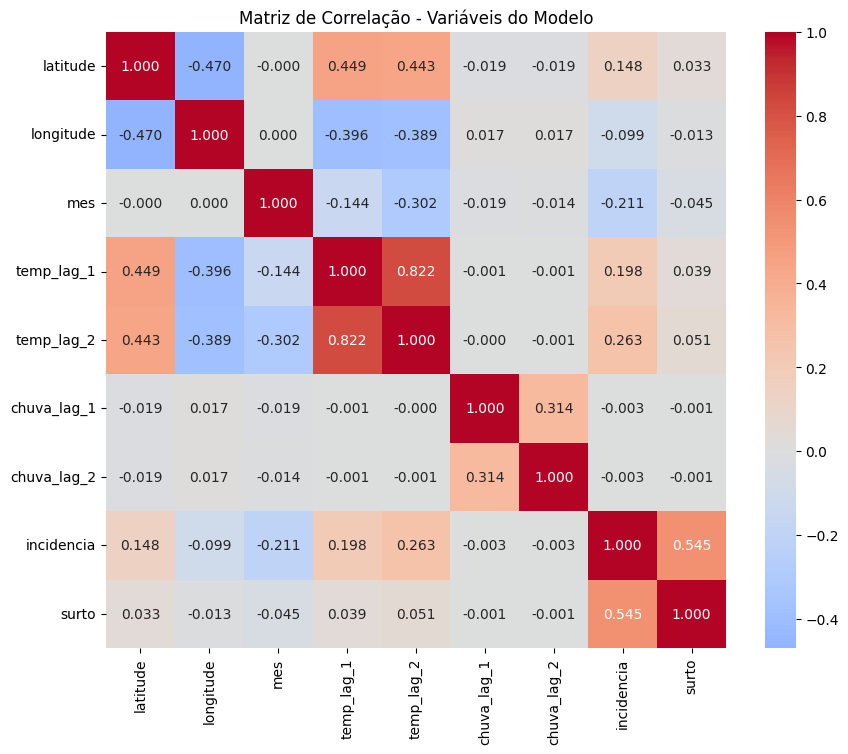

Correlação com o target 'surto':
surto          1.000000
incidencia     0.545128
temp_lag_2     0.051308
temp_lag_1     0.039219
latitude       0.033380
chuva_lag_1   -0.000650
chuva_lag_2   -0.000717
longitude     -0.013217
mes           -0.044674
Name: surto, dtype: float64


In [ ]:
# ANÁLISE DE CORRELAÇÃO

features_analise = ['latitude', 'longitude', 'mes',
                    'temp_lag_1', 'temp_lag_2',
                    'chuva_lag_1', 'chuva_lag_2',
                    'incidencia', 'surto']

corr_matrix = df_final_v2[features_analise].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Matriz de Correlação - Variáveis do Modelo')
plt.show()

# Correlação com o target
print("Correlação com o target 'surto':")
print(corr_matrix['surto'].sort_values(ascending=False))

Preparando dados para o modelo...
Aplicando SMOTE para balancear a classe de 'surtos' no Treino...
Distribuição do Treino após SMOTE:
surto
0    29624
1    29624
Name: count, dtype: int64

Treinando Regressão Logística...

 RESULTADO DO MODELO (2019):
              precision    recall  f1-score   support

           0       1.00      0.69      0.81      7703
           1       0.01      0.59      0.02        37

    accuracy                           0.69      7740
   macro avg       0.50      0.64      0.42      7740
weighted avg       0.99      0.69      0.81      7740



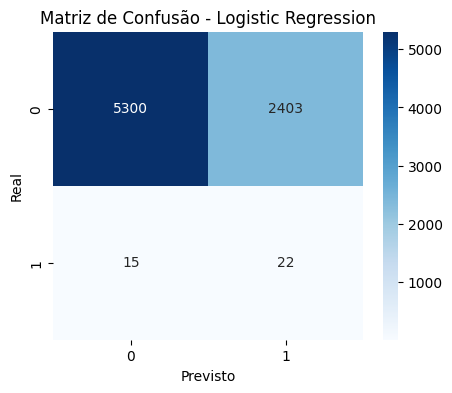

In [ ]:

# LOGISTIC REGRESSION - TESTE

print("Preparando dados para o modelo...")

# 1. Definindo as variáveis preditoras (X) e o alvo (y)
features_modelo = ['temp_lag_1', 'temp_lag_2', 'chuva_lag_1', 'chuva_lag_2', 'latitude', 'longitude']
X = df_final_v2[features_modelo]
y = df_final_v2['surto']

# 2. Refazendo o Split Cronológico
mask_treino = df_final_v2['ano'] < 2019
X_train, X_test = X[mask_treino], X[~mask_treino]
y_train, y_test = y[mask_treino], y[~mask_treino]

print("Aplicando SMOTE para balancear a classe de 'surtos' no Treino...")
# 3. Aplicando o SMOTE (Apenas no Treino, para não vazar dados!)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Distribuição do Treino após SMOTE:\n{y_train_res.value_counts()}")

# 4. Treinando o Modelo
print("\nTreinando Regressão Logística...")
log_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_model.fit(X_train_res, y_train_res)

# 5. Avaliando no Teste (2019)
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print("\n RESULTADO DO MODELO (2019):")
print(classification_report(y_test, y_pred))

# Matriz de Confusão Rápida
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Logistic Regression')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np
from sklearn.linear_model import LogisticRegression

# 1. Configurar a validação cruzada temporal
tscv = TimeSeriesSplit(n_splits=5)
scores = []

# Converter para matrizes NumPy (Usando o X_train_res que já está escalado e balanceado!)
X_array = np.array(X_train_res)
y_array = np.array(y_train_res)

print("Validando a estabilidade do modelo no tempo...")

# 2. Loop de validação
for train_index, test_index in tscv.split(X_array):
    X_t, X_v = X_array[train_index], X_array[test_index]
    y_t, y_v = y_array[train_index], y_array[test_index]

    # Treinar um modelo novo para cada janela de tempo
    modelo_cv = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    modelo_cv.fit(X_t, y_t)
    scores.append(modelo_cv.score(X_v, y_v))

# 3. Resultado Final
print(f"Estabilidade (Acurácia Média): {np.mean(scores):.2f} (+/- {np.std(scores):.2f})")

Validando a estabilidade do modelo no tempo...
Estabilidade (Acurácia Média): 0.85 (+/- 0.06)


RESULTADOS DA REGRESSÃO LOGÍSTICA:
      Variável  Coeficiente (Beta)  Odds Ratio (Razão de Chance)
1   temp_lag_2            7.546541                   1894.179087
5    longitude            1.768110                      5.859766
4     latitude            0.462297                      1.587716
2  chuva_lag_1           -0.000002                      0.999998
3  chuva_lag_2           -0.028640                      0.971767
0   temp_lag_1           -2.202441                      0.110533


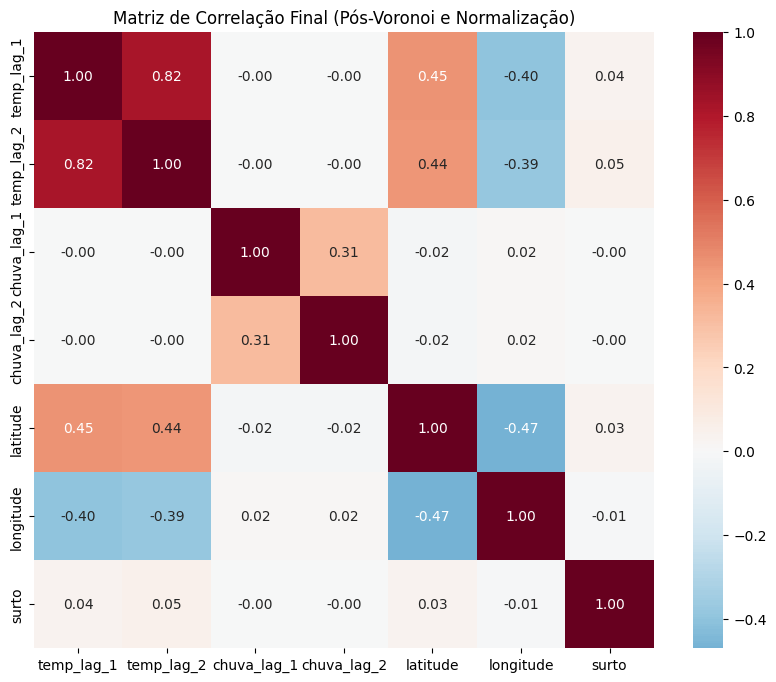

In [ ]:
# 1. Extrair Coeficientes do modelo treinado na Célula 14
coef_df = pd.DataFrame({
    'Variável': features_modelo,
    'Coeficiente (Beta)': log_model.coef_[0],
    'Odds Ratio (Razão de Chance)': np.exp(log_model.coef_[0])
})

print("RESULTADOS DA REGRESSÃO LOGÍSTICA:")
print(coef_df.sort_values(by='Coeficiente (Beta)', ascending=False))

# 2. Matriz de Correlação Final
plt.figure(figsize=(10, 8))
corr = df_final_v2[features_modelo + ['surto']].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Matriz de Correlação Final (Pós-Voronoi e Normalização)')
plt.show()

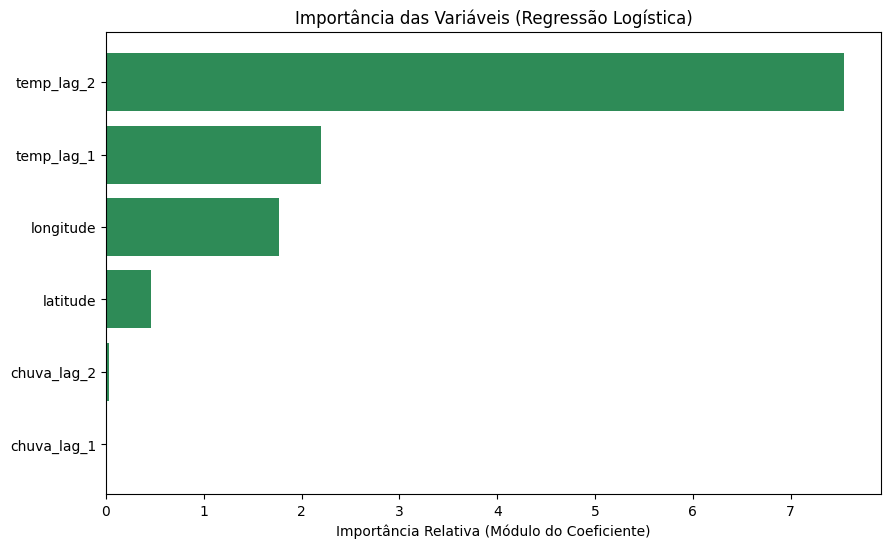

Valores de Importância:
temp_lag_2: 7.5465
temp_lag_1: 2.2024
longitude: 1.7681
latitude: 0.4623
chuva_lag_2: 0.0286
chuva_lag_1: 0.0000


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Para Regressão Logística, a "importância" é o valor absoluto do coeficiente
importances = np.abs(log_model.coef_[0])
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Importância das Variáveis (Regressão Logística)')
plt.barh(range(len(indices)), importances[indices], color='seagreen', align='center')
plt.yticks(range(len(indices)), [features_modelo[i] for i in indices])
plt.xlabel('Importância Relativa (Módulo do Coeficiente)')
plt.show()

# Exibindo os valores do maior para o menor
print("Valores de Importância:")
for i in indices[::-1]:
    print(f"{features_modelo[i]}: {importances[i]:.4f}")

In [ ]:
# 1. Criar o DataFrame de análise para o novo modelo
df_analise_v2 = df_test.copy()
df_analise_v2['probabilidade_surto'] = y_prob
df_analise_v2['previsao_modelo'] = y_pred

# 2. Filtrar os acertos reais (Onde era surto e o modelo previu surto)
acertos_v2 = df_analise_v2[(df_analise_v2['surto'] == 1) & (df_analise_v2['previsao_modelo'] == 1)]

# 3. Exibir os municípios com maior incidência que o modelo conseguiu prever
print(f"O modelo conseguiu prever surtos em {acertos_v2['nome_municipio'].nunique()} cidades diferentes no ano de 2019!")
print("\n TOP 10 ACERTOS DE SURTO (2019):")
colunas_exibicao = ['nome_municipio', 'mes', 'incidencia', 'chuva_lag_2', 'temp_lag_2', 'probabilidade_surto']
acertos_v2[colunas_exibicao].sort_values(by='incidencia', ascending=False).head(10)

O modelo conseguiu prever surtos em 18 cidades diferentes no ano de 2019!

 TOP 10 ACERTOS DE SURTO (2019):


,nome_municipio,mes,incidencia,chuva_lag_2,temp_lag_2,probabilidade_surto
26630,Pontes Gestal,3,526.752385,0.142084,1.183486,0.974405
26211,Planalto,4,501.011009,-0.297578,1.018349,0.949416
24351,Paulo de Faria,4,500.676590,1.533651,0.876147,0.924377
3889,Bilac,2,471.596999,-0.297578,1.006881,0.790499
33529,São Joaquim da Barra,2,471.484414,-0.297578,0.580275,0.643588
22791,Orindiúva,4,458.015267,1.533651,0.876147,0.926918
37129,União Paulista,2,454.545455,2.478577,1.061927,0.872620
26631,Pontes Gestal,4,452.094567,0.544061,1.016055,0.956046
7011,Catiguá,4,450.640755,-0.297578,0.827982,0.927422
36711,Tupã,4,447.633457,-0.297578,0.779817,0.702632


In [ ]:
# EXPORTAÇÃO DOS DADOS FINALIZADOS


caminho_final = '/content/drive/Shareddrives/Data Project - Equipe 3/Dados/base_dengue_normalizada.csv'

# Salvando a base completa
df_final_v2.to_csv(caminho_final, index=False)

print(f"Base exportada em: {caminho_final}")

Base exportada em: /content/drive/Shareddrives/Data Project - Equipe 3/Dados/base_dengue_normalizada.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')